<a href="https://colab.research.google.com/github/erigitola/-Random-User--Generator--using--API/blob/main/EXPIRED_PRODUCT_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load dataset
df = pd.read_csv('/content/EXPRIED PRODUCT..csv')

df.head()

,product_name,category,vendor,quantity,cost,amount
0,PRIME GLOWBERRY HYDRATION DRINK 500ML,SANITARY,Contemporary gift,13,3166.66660,41166.66580
1,UTTERLY YUM PINEAPPLE JUICE 50CL,SANITARY,Utterfresh,15,1300.00000,19500.00000
2,ALPRO BARISTA OAT 1L,0,Contemporary gift,6,4125.00000,24750.00000
3,WELCHS ZERO SUGAR JUICE VARIETY PACK 295ML,0,Contemporary gift,14,1604.00000,22456.00000
4,STARBUCKS DOUBLESHOT ESPRESSO 200ML,SANITARY,Contemporary gift,12,2708.33333,32499.99996


In [ ]:
# Descriptive Statistics Summary
df.describe()

,quantity,cost,amount
count,6.000000,6.000000,6.000000
mean,10.166667,3317.333322,24562.110960
std,5.492419,2079.090454,11638.256206
min,1.000000,1300.000000,7000.000000
25%,7.500000,1880.083332,20239.000000
50%,12.500000,2937.499965,23603.000000
75%,13.750000,3885.416650,30562.499970
max,15.000000,7000.000000,41166.665800


In [ ]:
# Total expired Loss
total_loss = df["amount"].sum()

total_loss

np.float64(147372.66576)

In [ ]:
# Expired value by product
product_loss = df.groupby("product_name")[["quantity","amount"]].sum().reset_index()

# Sort by highest loss
product_loss = product_loss.sort_values("amount", ascending=False)

product_loss



,product_name,quantity,amount
2,PRIME GLOWBERRY HYDRATION DRINK 500ML,13,41166.66580
3,STARBUCKS DOUBLESHOT ESPRESSO 200ML,12,32499.99996
0,ALPRO BARISTA OAT 1L,6,24750.00000
5,WELCHS ZERO SUGAR JUICE VARIETY PACK 295ML,14,22456.00000
4,UTTERLY YUM PINEAPPLE JUICE 50CL,15,19500.00000
1,DECLAN SPARKLING RED GRAPE NON-ALCOHOLIC 75CL,1,7000.00000


In [ ]:
# Loss by category
category_loss = df.groupby("category")[["quantity","amount"]].sum().reset_index()
category_loss = category_loss.sort_values("amount", ascending=False)

category_loss


,category,quantity,amount
2,SANITARY,40,93166.66576
0,0,20,47206.00000
1,CHRISTMAS,1,7000.00000


In [ ]:
# Loss by vendor
vendor_loss = df.groupby("vendor")[["quantity","amount"]].sum().reset_index()
vendor_loss = vendor_loss.sort_values("amount", ascending=False)

vendor_loss


,vendor,quantity,amount
0,Contemporary gift,45,120872.66576
2,Utterfresh,15,19500.00000
1,Kareem Yawande,1,7000.00000


In [ ]:
# ----------------------------------------
# LOSS PERCENTAGE DISTRIBUTION
# ----------------------------------------

# Calculate total expired loss
total_loss = df["amount"].sum()

# Create product loss summary
product_loss = df.groupby("product_name")["amount"].sum().reset_index()

# Calculate loss percentage per product
product_loss["loss_percentage"] = (product_loss["amount"] / total_loss) * 100

# Sort from highest to lowest loss contribution
product_loss = product_loss.sort_values("loss_percentage", ascending=False)

product_loss


,product_name,amount,loss_percentage
2,PRIME GLOWBERRY HYDRATION DRINK 500ML,41166.66580,27.933719
3,STARBUCKS DOUBLESHOT ESPRESSO 200ML,32499.99996,22.052936
0,ALPRO BARISTA OAT 1L,24750.00000,16.794159
5,WELCHS ZERO SUGAR JUICE VARIETY PACK 295ML,22456.00000,15.237561
4,UTTERLY YUM PINEAPPLE JUICE 50CL,19500.00000,13.231762
1,DECLAN SPARKLING RED GRAPE NON-ALCOHOLIC 75CL,7000.00000,4.749863


In [ ]:

# LOSS PERCENTAGE BY CATEGORY


category_loss = df.groupby("category")["amount"].sum().reset_index()

category_loss["loss_percentage"] = (category_loss["amount"] / total_loss) * 100

category_loss = category_loss.sort_values("loss_percentage", ascending=False)

category_loss


,category,amount,loss_percentage
2,SANITARY,93166.66576,63.218417
0,0,47206.00000,32.031720
1,CHRISTMAS,7000.00000,4.749863


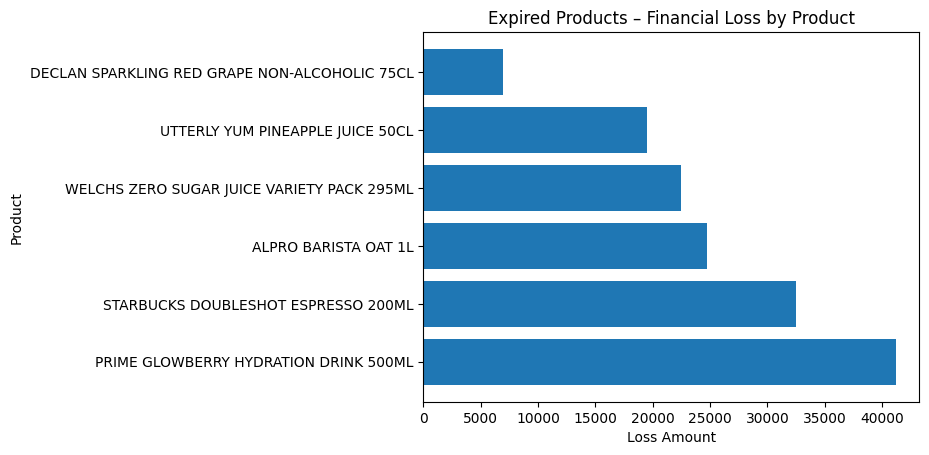

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(product_loss["product_name"], product_loss["amount"])
plt.title("Expired Products – Financial Loss by Product")
plt.xlabel("Loss Amount")
plt.ylabel("Product")
plt.show()
